<a href="https://colab.research.google.com/github/RHM-Romim/NSDA-Level6_tasks/blob/main/Set1_job2_Weather%20Prediction%20System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
Job 02-Working Procedure/ Steps:
1. Wear the required Personal Protective Equipment (PPE) for the job.
2. Observe and follow appropriate occupational health and safety (OHS)
requirements during the demonstration.
3. Check Electricity, Peripheral device & Internet Connections to your Computer.
4. Start the Computer.
5. Check for software errors and troubleshoot problems.
6. Collect the resources (Dataset) and materials from your assessor as per the
job requirement.
7. Create a Weather Prediction System
8. Set up the Python environment required to create the system.
9. Load the weather dataset into the environment.
10.Perform initial data inspection.
11. Define the ML Problem Statement
12.Perform Feature Selection
13.Split the dataset for training and testing
14.Implement a baseline ML model
15.Apply feature scaling, compare model performance before and after scaling
16.Train other optimized ML models (at least 2 Model)
17.Evaluate Model Performance
18.Visualize Model Performance
19.Detect Overfitting and Underfitting
20.Save and deploy the final model
21.Submit the final output to the competency assessor.
22.Shut down the computer and clean your workplace.
23.Clean tools, equipment, materials, and work area.
```



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/Job_2_resource_Weather Test Data.csv')

In [ ]:
df.head()

,row ID,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
0,Row0,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No
1,Row1,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No
2,Row2,Albury,14.3,25.0,0.0,NaN,NaN,W,50.0,SW,...,24.0,49.0,19.0,1009.6,1008.2,1.0,NaN,18.1,24.6,No
3,Row3,Albury,9.7,31.9,0.0,NaN,NaN,NNW,80.0,SE,...,28.0,42.0,9.0,1008.9,1003.6,NaN,NaN,18.3,30.2,No
4,Row4,Albury,15.9,18.6,15.6,NaN,NaN,W,61.0,NNW,...,28.0,76.0,93.0,994.3,993.0,8.0,8.0,17.4,15.8,Yes


In [ ]:
df.shape

(42677, 22)

In [ ]:
df.isnull().sum()

,0
row ID,0
Location,0
MinTemp,194
MaxTemp,92
Rainfall,427
Evaporation,18312
Sunshine,20499
WindGustDir,2809
WindGustSpeed,2790
WindDir9am,3007


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
row ID,0
Location,0
MinTemp,0
MaxTemp,0
Rainfall,0
Evaporation,0
Sunshine,0
WindGustDir,0
WindGustSpeed,0
WindDir9am,0


In [ ]:
df.shape

(16846, 22)

In [ ]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,16846.000000,16846.000000,16846.000000,16846.000000,16846.000000,16846.000000,16846.000000,16846.000000,16846.000000,16846.000000,16846.00000,16846.000000,16846.000000,16846.000000,16846.000000,16846.000000
mean,13.472652,24.236169,2.053485,5.522237,7.764555,40.845067,15.614864,19.768966,65.882346,49.687582,1017.17730,1014.735154,4.208002,4.285884,18.223762,22.722646
std,6.481411,6.981875,6.990011,3.692763,3.759481,13.379706,8.292799,8.460839,18.419450,20.224100,6.86216,6.815424,2.794741,2.654221,6.611865,6.853896
min,-5.200000,4.100000,0.000000,0.000000,0.000000,9.000000,2.000000,2.000000,1.000000,1.000000,982.20000,977.100000,0.000000,0.000000,-0.700000,3.700000
25%,8.500000,18.700000,0.000000,2.800000,5.100000,31.000000,9.000000,13.000000,55.000000,35.000000,1012.60000,1010.100000,1.000000,2.000000,13.000000,17.300000
50%,13.200000,24.000000,0.000000,5.000000,8.700000,39.000000,15.000000,19.000000,67.000000,51.000000,1017.10000,1014.600000,5.000000,5.000000,17.900000,22.500000
75%,18.500000,29.700000,0.600000,7.500000,10.700000,48.000000,20.000000,26.000000,79.000000,63.000000,1021.80000,1019.300000,7.000000,7.000000,23.300000,27.900000
max,29.700000,46.400000,206.200000,72.200000,14.300000,122.000000,67.000000,61.000000,100.000000,100.000000,1040.40000,1038.900000,8.000000,8.000000,39.400000,45.400000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16846 entries, 1756 to 41701
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row ID         16846 non-null  object 
 1   Location       16846 non-null  object 
 2   MinTemp        16846 non-null  float64
 3   MaxTemp        16846 non-null  float64
 4   Rainfall       16846 non-null  float64
 5   Evaporation    16846 non-null  float64
 6   Sunshine       16846 non-null  float64
 7   WindGustDir    16846 non-null  object 
 8   WindGustSpeed  16846 non-null  float64
 9   WindDir9am     16846 non-null  object 
 10  WindDir3pm     16846 non-null  object 
 11  WindSpeed9am   16846 non-null  float64
 12  WindSpeed3pm   16846 non-null  float64
 13  Humidity9am    16846 non-null  float64
 14  Humidity3pm    16846 non-null  float64
 15  Pressure9am    16846 non-null  float64
 16  Pressure3pm    16846 non-null  float64
 17  Cloud9am       16846 non-null  float64
 18  Cloud3pm

In [ ]:
df.columns

Index(['row ID', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday'],
      dtype='object')

In [ ]:
df.select_dtypes(include='object').columns

Index(['row ID', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday'],
      dtype='object')

In [ ]:
df.drop('row ID',axis=1,inplace=True)

In [ ]:
df.select_dtypes(include ='object').columns

Index(['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday'], dtype='object')



> Because of objects(calagorical data) we do types of encoding . Here we do level encoding in here



In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
col_encode = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

for col in col_encode:
  df[col] = le.fit_transform(df[col])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16846 entries, 1756 to 41701
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Location       16846 non-null  int64  
 1   MinTemp        16846 non-null  float64
 2   MaxTemp        16846 non-null  float64
 3   Rainfall       16846 non-null  float64
 4   Evaporation    16846 non-null  float64
 5   Sunshine       16846 non-null  float64
 6   WindGustDir    16846 non-null  int64  
 7   WindGustSpeed  16846 non-null  float64
 8   WindDir9am     16846 non-null  int64  
 9   WindDir3pm     16846 non-null  int64  
 10  WindSpeed9am   16846 non-null  float64
 11  WindSpeed3pm   16846 non-null  float64
 12  Humidity9am    16846 non-null  float64
 13  Humidity3pm    16846 non-null  float64
 14  Pressure9am    16846 non-null  float64
 15  Pressure3pm    16846 non-null  float64
 16  Cloud9am       16846 non-null  float64
 17  Cloud3pm       16846 non-null  float64
 18  Temp9am 

In [ ]:
df.dtypes


,0
Location,int64
MinTemp,float64
MaxTemp,float64
Rainfall,float64
Evaporation,float64
Sunshine,float64
WindGustDir,int64
WindGustSpeed,float64
WindDir9am,int64
WindDir3pm,int64




> 2 types of problem in upervise learning
1. regression
2. classification

in here it is classifiacation based problem because the terget data(ouput col) has yes and no data if it has 1,0 then it still clasiffication based problem.



# Feature selection

In [ ]:
x =df.drop('RainToday',axis=1)

In [ ]:
x.columns

Index(['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm'],
      dtype='object')

In [ ]:
y =  df['RainToday']

In [ ]:
y.head()

,RainToday
1756,0
1757,0
1758,0
1759,0
1760,0


# Training and testing

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=42)

In [ ]:
X_train.shape

(13476, 20)

In [ ]:
X_test.shape

(3370, 20)

# Baseine ML model : in here logistic regration(classification algorithm)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression()

In [ ]:
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

# Apply feature scaling, compare model performance before and after scaling

to scale the inputs we take help of standard scaler

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train other optimized ML models (at least 2 Model)

1. DecisionTreeClassifier
2. RandomForestClassifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model2 = DecisionTreeClassifier()
model2.fit(X_train,y_train)

DecisionTreeClassifier()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model3 = RandomForestClassifier()
model3.fit(X_train,y_train)

RandomForestClassifier()

# Evaluate Model Performance

In [53]:
logistic_regression_performance = model.score(X_test,y_test)
logistic_regression_performance

0.9875370919881306

In [54]:
decision_tree_performance = model2.score(X_test,y_test)
decision_tree_performance

1.0

In [55]:
random_forest_performance = model3.score(X_test,y_test)
random_forest_performance


1.0

In [56]:
print(f'Logistic Regression Performance: {logistic_regression_performance}')
print(f'Decision Tree Performance: {decision_tree_performance}')
print(f'Random Forest Performance: {random_forest_performance}')

Logistic Regression Performance: 0.9875370919881306
Decision Tree Performance: 1.0
Random Forest Performance: 1.0


# Visualize Model Performance

Text(0.5, 1.0, 'Model Performance Comparison')

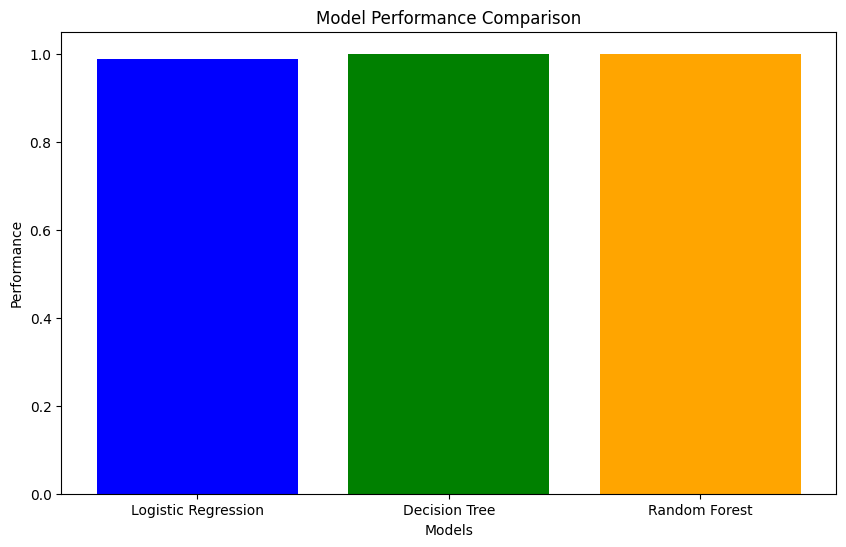

In [58]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
performances = [logistic_regression_performance, decision_tree_performance, random_forest_performance]
plt.figure(figsize=(10, 6))
plt.bar(models, performances, color=['blue', 'green', 'orange'])
plt.xlabel('Models')
plt.ylabel('Performance')
plt.title('Model Performance Comparison')

# Detect Overfitting and Underfitting

In [61]:
from sklearn.metrics import accuracy_score
#trainning accuracy
y_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_pred)
print(f'Training Accuracy: {train_accuracy}')

#testing accuracy
y_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f'Testing Accuracy: {test_accuracy}')



Training Accuracy: 0.9890175126150192
Testing Accuracy: 0.9875370919881306


In [62]:
#check underfit, overfit and bestfit
if train_accuracy > 0.90 and test_accuracy < 0.70:
  print("The model is overfitting: High training accuracy, low testing accuracy.")
elif train_accuracy < 0.70 and test_accuracy < 0.70:
  print("The model is underfitting: Both training and testing accuracies are low.")
else:
  print("The model is a good fit: Training and testing accuracies are balanced.")

The model is a good fit: Training and testing accuracies are balanced.


# Save and deploy the final model

In [63]:
import joblib

joblib.dump(model, 'weather_predict_model.joblib')
joblib.dump(scaler,'scaler.joblib')

['scaler.joblib']